**Example A**

*We are going to use 2 layers

*We are going to use without Normalization

**Example B**

*We are going to use 3 layers

*Optimizer we are going to use Adam

*We are going to use without Normalization

**Example C**

*We are going to use 2 layers

*ptimizer we are going to use Adam

*We are going to use with Normalization and standardization

In [175]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [176]:
insurance_data=pd.read_csv('/content/insurance_data.csv')
insurance.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [177]:
insurance_data_one_hot=pd.get_dummies(insurance_data)
insurance_data_one_hot.head(10)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,True,False


In [178]:
X=insurance_data_one_hot.drop('charges',axis=1)
y=insurance_data_one_hot['charges']
#

In [179]:
print('Features are:')
X.head()

Features are:


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,True
1,18,33.770,1,False,True,True,False,False,True,False
2,28,33.000,3,False,True,True,False,False,True,False
3,33,22.705,0,False,True,True,False,True,False,False
4,32,28.880,0,False,True,True,False,True,False,False


In [180]:
print('Charges')
y.head()

Charges


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [181]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [182]:
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
])

In [183]:
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

In [184]:
history_model1=insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - loss: 8509.1357 - mae: 8509.1357
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8498.2480 - mae: 8498.2480
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 8480.1602 - mae: 8480.1602
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8445.2041 - mae: 8445.2041
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8375.6230 - mae: 8375.6230
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 8236.3896 - mae: 8236.3896
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 7957.5220 - mae: 7957.5220
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 7398.8940 - mae: 7398.8940
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 6279.8086 - mae: 6279.8086
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4818.5679 - mae: 4818.5679
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 5768.7358 - mae: 5768.7358
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 534

In [185]:
insurance_model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 7754.6274 - mae: 7754.6274


[7754.62744140625, 7754.62744140625]

***Exercise - B***

In [186]:
tf.random.set_seed(42)
insurance_model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

history_model2=insurance_model_2.fit(X_train, y_train, epochs=150,verbose=0)

In [187]:
insurance_model_2.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 7789.3374 - mae: 7789.3374


[7789.33740234375, 7789.33740234375]

In [188]:
insurance_model_2_loss=insurance_model_2.evaluate(X_test,y_test)

print('Loss:',insurance_model_2_loss)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7789.3374 - mae: 7789.3374
Loss: [7789.33740234375, 7789.33740234375]


Text(0.5, 1.0, 'Loss vs Epochs')

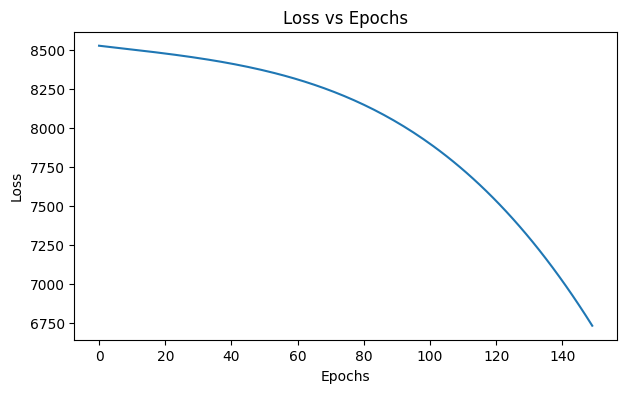

In [189]:
plt.figure(figsize=(7,4))
plt.plot(history_model2.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')



***Exercise - 3***

In [201]:
df=pd.read_csv('/content/insurance_data.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [203]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [191]:
ct=make_column_transformer(
    (MinMaxScaler(),['age','bmi','children']),
    (OneHotEncoder(handle_unknown='ignore'),['sex','smoker','region'])
)

In [204]:
X=df.drop('charges',axis=1)
y=df['charges']
#

In [205]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [206]:
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [207]:
X_train_normal=ct.transform(X_train)
X_test_normal=ct.transform(X_test)

In [208]:
# non normalized data
X_train

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [209]:
# Normalized data
X_train_normal

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [211]:
tf.random.set_seed(42)

model3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])


model3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                          metrics=['mae']
                          )


model3_history = model3.fit(X_train_normal, y_train, epochs=200,verbose=0)

In [212]:
model3.evaluate(X_test_normal,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 9180.2891 - mae: 9180.2891


[9180.2890625, 9180.2890625]

Text(0.5, 1.0, 'Loss vs Epochs')

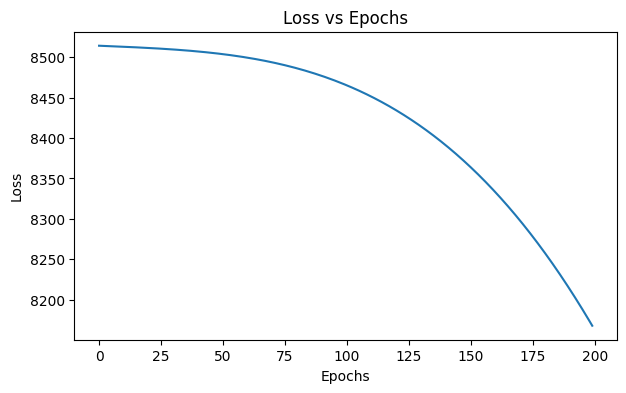

In [213]:
plt.figure(figsize=(7,4))
plt.plot(model3_history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
